# Nice Plot Viz for Publications

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm
import networkx as nx

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/OtherLibraries/pyedm4hep")
from pyedm4hep import EDM4hepEvent
sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks")
from loading_utils import load_root_file, load_hepmc_event

In [3]:
import math, re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def parse_size_to_gb(s: str):
    s = s.strip().lower().replace(',', '')
    if not s or s in ('??', '--', 'unknown'):
        return math.nan
    tokens = re.findall(r'[\d\.]+|[a-zA-Z]+', s)
    val, unit = None, 'gb'
    for t in tokens:
        if t.replace('.','',1).isdigit():
            val = float(t)
        else:
            unit = t.lower()
    if val is None:
        return math.nan
    if unit in ('pb',):  return val * 1_000_000.0
    if unit in ('tb',):  return val * 1_000.0
    if unit in ('gb',):  return val
    if unit in ('gib',): return val * (1024.0/1000.0)
    if unit in ('tib',): return val * 1024.0 * (1024.0/1000.0)
    if unit in ('pib',): return val * 1024.0 * 1024.0 * (1024.0/1000.0)
    return val

rows = [
    ("LHCO2020",        "Analysis", 4_000_000, "10.9 GB"),
    ("Dark Machines",   "Analysis", 1_000_000_000, ""),  # excluded
    ("SUSY (UCI)",      "Analysis", 5_000_000, "0.88 GB"),
    ("JetClass",        "High", 125_000_000, "189.8 GB"),
    ("ATLAS Top Tagging OD", "High", 44_500_000, "129.2 GiB"),
    ("JetNet (30)", "High", 880_000, "0.44 GB"),
    ("JetNet (150)", "High", 880_000, "2.1 GB"),
    ("FAIR Higgs", "Medium", 6_000_000, "228 GiB"),
    ("CMS Open Data 2016", "Medium", 10_000_000_000, "900 TB"),
    ("ATLAS Open Data 2015-16", "Medium", 10_000_000_000, "100 TB"),
    ("CaloChallenge D2", "Low", 200_000, "2.7 GB"),
    ("CaloChallenge D3", "Low", 200_000, "7.6 GB"),
    ("TrackML", "Low", 10_000, "200 GB"),
    ("TPCpp-10M", "Low", 10_000_000, "120 GB"),
    ("ColliderML (HDF5)", "Low", 1_000_000, "1 TB"),
    ("ColliderML (EDM4hep)", "Low", 1_000_000, "100 TB"),
]

df = pd.DataFrame(rows, columns=["Dataset","Level","Samples","Size"])
df["Size_GB"] = df["Size"].apply(parse_size_to_gb)
df = df.dropna(subset=["Size_GB"]).copy()

level_order = ["Analysis","High","Medium","Low"]
df["Level"] = pd.Categorical(df["Level"], categories=level_order, ordered=True)
x_map = {lvl:i for i,lvl in enumerate(level_order)}
df["x"] = df["Level"].map(x_map).astype(float)

df.loc[df["Dataset"].str.contains("EDM4hep"), "x"] += 0.15

'../plots/by_level_samplesY_bubbleGB.png'

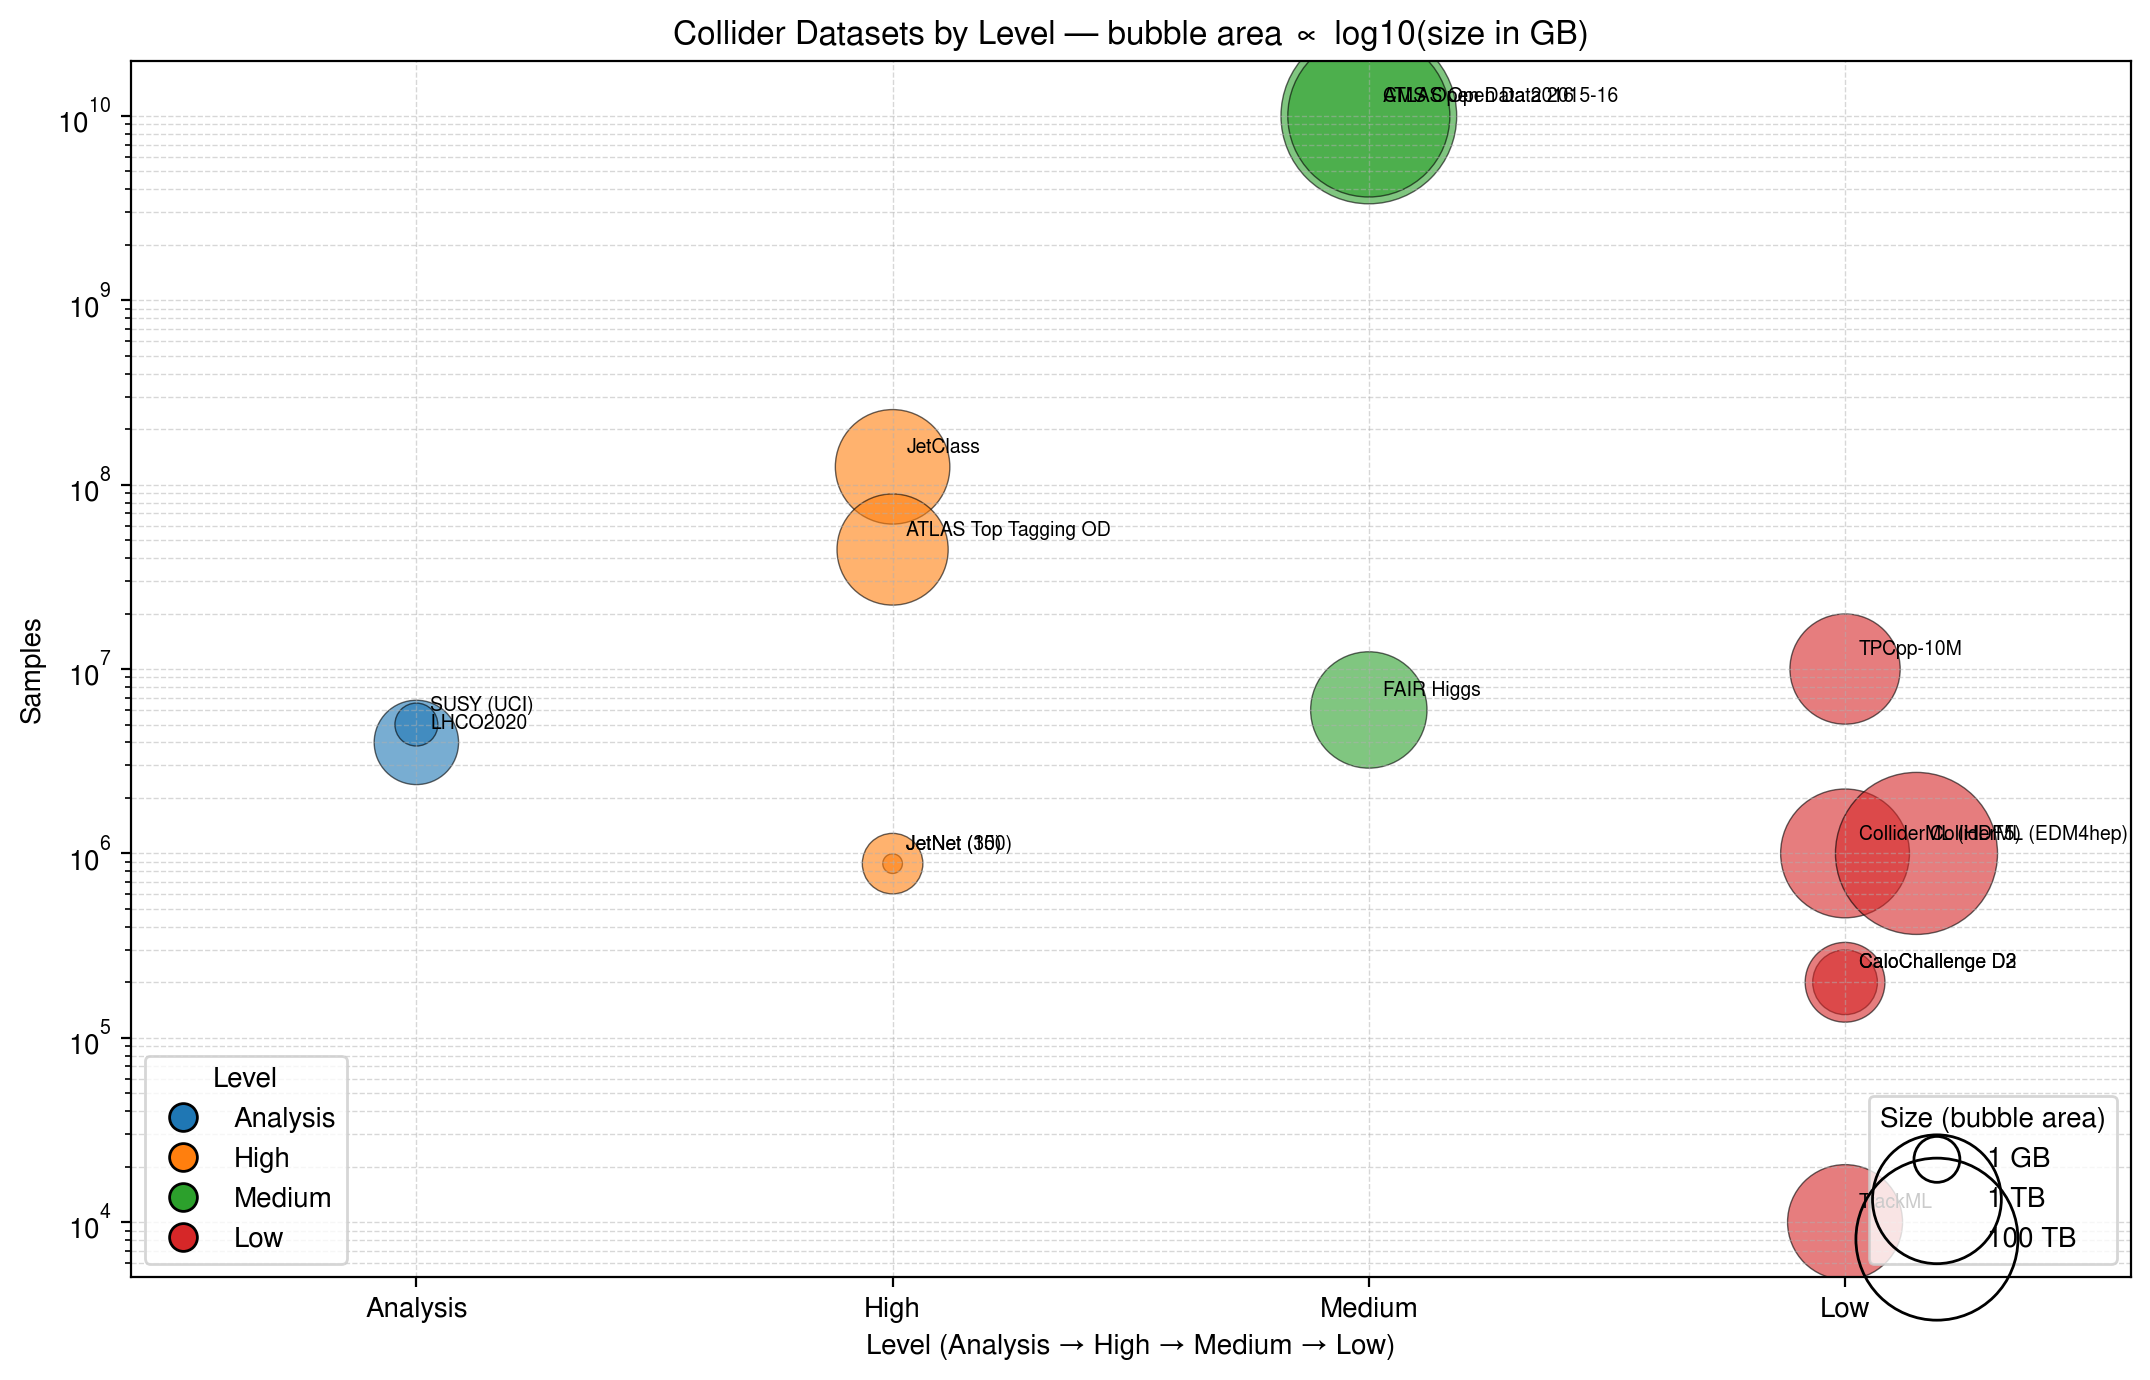

In [4]:
# bubble areas from log10(Size_GB)
import numpy as np
log_gb = np.log10(np.maximum(df["Size_GB"].values, 1e-6))
min_log, max_log = log_gb.min(), log_gb.max()
min_area, max_area = 50, 4000
def area_from_gb(g):
    lg = math.log10(max(g,1e-6))
    t = (lg - min_log) / (max_log - min_log) if max_log > min_log else 0.5
    return min_area + t*(max_area - min_area)
df["BubbleArea"] = df["Size_GB"].apply(area_from_gb)

# color by level
level_to_color = {lvl: plt.rcParams['axes.prop_cycle'].by_key()['color'][i % 10]
                  for i, lvl in enumerate(level_order)}
df["color"] = df["Level"].map(level_to_color)

# plot
fig, ax = plt.subplots(figsize=(11,7), dpi=200)
for lvl in level_order:
    sub = df[df["Level"] == lvl]
    if sub.empty: 
        continue
    ax.scatter(sub["x"], sub["Samples"], s=sub["BubbleArea"], marker='o',
               alpha=0.6, edgecolor="black", linewidth=0.5, c=sub["color"], label=lvl)

# annotations
for _, r in df.iterrows():
    ax.annotate(r["Dataset"], (r["x"], r["Samples"]), xytext=(5,5), textcoords="offset points", fontsize=7)

ax.set_yscale("log")
ax.set_xlim(-0.6, len(level_order)-0.4)
ax.set_xticks(list(x_map.values()), list(x_map.keys()))
ax.set_xlabel("Level (Analysis → High → Medium → Low)")
ax.set_ylabel("Samples")
ax.set_title("Collider Datasets by Level — bubble area ∝ log10(size in GB)")

# legends
from matplotlib.lines import Line2D
handles1 = [Line2D([0],[0], marker='o', color='w', markerfacecolor=level_to_color[lvl],
                   markersize=10, markeredgecolor='black', label=lvl) for lvl in level_order]
legend1 = ax.legend(handles=handles1, title="Level", loc="lower left", frameon=True)

legend_sizes_gb = [1, 1_000, 100_000]  # 1 GB, 1 TB, 100 TB
legend_areas = [area_from_gb(s) for s in legend_sizes_gb]
handles2 = [plt.scatter([], [], s=a, marker='o', edgecolor='black', facecolor='none') for a in legend_areas]
labels2 = ["1 GB", "1 TB", "100 TB"]
legend2 = ax.legend(handles2, labels2, title="Size (bubble area)", loc="lower right", frameon=True)
ax.add_artist(legend1)

ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.5)
plt.tight_layout()

png = "../plots/by_level_samplesY_bubbleGB.png"
plt.savefig(png)

png
